<a href="https://colab.research.google.com/github/kondapallijayasri739-glitch/Air-quality-prediction-/blob/main/Movie_review_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Movie Review Dataset
                         Review Sentiment
           The movie is amazing  Positive
             I loved the acting  Positive
Excellent story and great music  Positive
                 Fantastic film  Positive
         I enjoyed every minute  Positive
               Worst movie ever  Negative
              I hate this movie  Negative
                  Waste of time  Negative
              Very boring movie  Negative


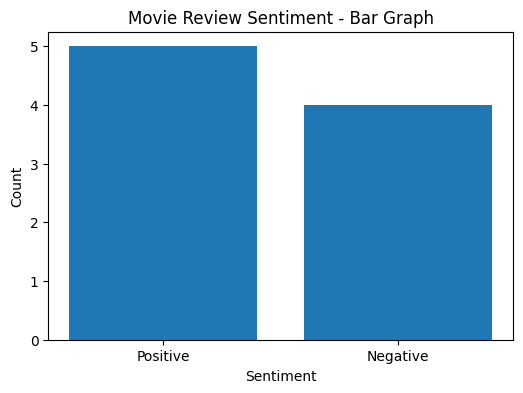

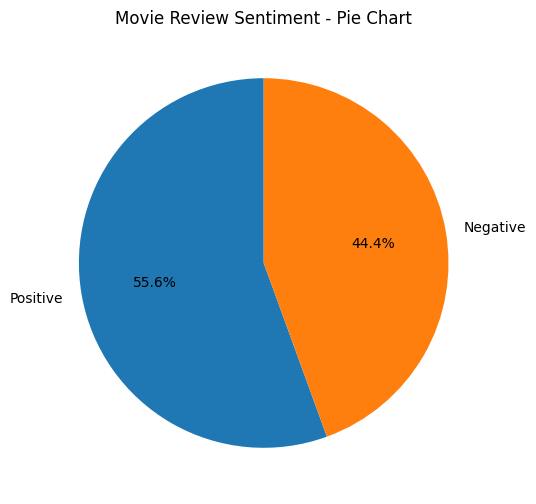


New Review: Amazing movie with excellent acting
Prediction: Positive Review


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Create Dataset
reviews = [
    "The movie is amazing",
    "I loved the acting",
    "Excellent story and great music",
    "Fantastic film",
    "I enjoyed every minute",
    "Worst movie ever",
    "I hate this movie",
    "Waste of time",
    "Very boring movie"
]

sentiments = [
    "Positive",
    "Positive",
    "Positive",
    "Positive",
    "Positive",
    "Negative",
    "Negative",
    "Negative",
    "Negative"
]

# Create DataFrame
df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": sentiments
})

# Save CSV
df.to_csv("Movie_Reviews.csv", index=False)

print("Movie Review Dataset")
print(df.to_string(index=False))

# Bar Graph
count = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(count.index, count.values)
plt.title("Movie Review Sentiment - Bar Graph")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(count.values,
        labels=count.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Movie Review Sentiment - Pie Chart")
plt.show()

# Convert labels
df["Sentiment"] = df["Sentiment"].map({
    "Positive":1,
    "Negative":0
})

# Train Model
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["Review"])
y = df["Sentiment"]

model = MultinomialNB()
model.fit(X, y)

# Predict New Review
test_review = ["Amazing movie with excellent acting"]
test = vectorizer.transform(test_review)
prediction = model.predict(test)

print("\nNew Review:", test_review[0])

if prediction[0] == 1:
    print("Prediction: Positive Review")
else:
    print("Prediction: Negative Review")